In [4]:
import requests

# URL da API
url = "https://jsonplaceholder.typicode.com/posts"

# Cabeçalho personalizado
headers = {
    "User-Agent": "MeuProjetoPython/1.0"
}

# Parâmetros: buscar apenas posts do userId 2
params = {
    "userId": 2
}

# Requisição GET
resposta = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=10
)

# Exibindo os resultados solicitados
print("Código de status:", resposta.status_code)
print("URL final:", resposta.url)

# Visualizando os dados
print("\nPrimeiros resultados:")
print(resposta.json()[:3])

Código de status: 200
URL final: https://jsonplaceholder.typicode.com/posts?userId=2

Primeiros resultados:
[{'userId': 2, 'id': 11, 'title': 'et ea vero quia laudantium autem', 'body': 'delectus reiciendis molestiae occaecati non minima eveniet qui voluptatibus\naccusamus in eum beatae sit\nvel qui neque voluptates ut commodi qui incidunt\nut animi commodi'}, {'userId': 2, 'id': 12, 'title': 'in quibusdam tempore odit est dolorem', 'body': 'itaque id aut magnam\npraesentium quia et ea odit et ea voluptas et\nsapiente quia nihil amet occaecati quia id voluptatem\nincidunt ea est distinctio odio'}, {'userId': 2, 'id': 13, 'title': 'dolorum ut in voluptas mollitia et saepe quo animi', 'body': 'aut dicta possimus sint mollitia voluptas commodi quo doloremque\niste corrupti reiciendis voluptatem eius rerum\nsit cumque quod eligendi laborum minima\nperferendis recusandae assumenda consectetur porro architecto ipsum ipsam'}]


Limitando a quantidade de resultados

In [5]:
params = {
    "userId": 2,
    "_limit": 5
}

resposta = requests.get(
    url,
    params=params,
    headers=headers,
    timeout=10
)

print("Status:", resposta.status_code)
print("URL:", resposta.url)

dados = resposta.json()

print("Quantidade de resultados:", len(dados))
print(dados)

Status: 200
URL: https://jsonplaceholder.typicode.com/posts?userId=2&_limit=5
Quantidade de resultados: 5
[{'userId': 2, 'id': 11, 'title': 'et ea vero quia laudantium autem', 'body': 'delectus reiciendis molestiae occaecati non minima eveniet qui voluptatibus\naccusamus in eum beatae sit\nvel qui neque voluptates ut commodi qui incidunt\nut animi commodi'}, {'userId': 2, 'id': 12, 'title': 'in quibusdam tempore odit est dolorem', 'body': 'itaque id aut magnam\npraesentium quia et ea odit et ea voluptas et\nsapiente quia nihil amet occaecati quia id voluptatem\nincidunt ea est distinctio odio'}, {'userId': 2, 'id': 13, 'title': 'dolorum ut in voluptas mollitia et saepe quo animi', 'body': 'aut dicta possimus sint mollitia voluptas commodi quo doloremque\niste corrupti reiciendis voluptatem eius rerum\nsit cumque quod eligendi laborum minima\nperferendis recusandae assumenda consectetur porro architecto ipsum ipsam'}, {'userId': 2, 'id': 14, 'title': 'voluptatem eligendi optio', 'body':

# Nível 2 — JSON, erros e arquivos binários
Exercício 2.1 — Consulta de CEPs

In [6]:
import requests
import pandas as pd

# Lista com três CEPs
ceps = [
    "01001000",
    "20040002",
    "30130010"
]

resultados = []

for cep in ceps:
    url = f"https://viacep.com.br/ws/{cep}/json/"

    resposta = requests.get(url, timeout=10)

    # Converte o JSON para dicionário Python
    dados = resposta.json()

    resultados.append(dados)

# Criando o DataFrame
df_ceps = pd.DataFrame(resultados)

df_ceps

,cep,logradouro,complemento,unidade,bairro,localidade,uf,estado,regiao,ibge,gia,ddd,siafi
0,01001-000,Praça da Sé,lado ímpar,,Sé,São Paulo,SP,São Paulo,Sudeste,3550308,1004,11,7107
1,20040-002,Avenida Rio Branco,de 128 a 144 - lado par,,Centro,Rio de Janeiro,RJ,Rio de Janeiro,Sudeste,3304557,,21,6001
2,30130-010,Praça Sete de Setembro,,,Centro,Belo Horizonte,MG,Minas Gerais,Sudeste,3106200,,31,4123


In [7]:
df_ceps[["cep", "logradouro", "bairro", "localidade", "uf"]]

,cep,logradouro,bairro,localidade,uf
0,01001-000,Praça da Sé,Sé,São Paulo,SP
1,20040-002,Avenida Rio Branco,Centro,Rio de Janeiro,RJ
2,30130-010,Praça Sete de Setembro,Centro,Belo Horizonte,MG


Exercício 2.2 — Função de download segura

In [8]:
import requests

def baixar_arquivo(url, nome_arquivo):
    try:
        resposta = requests.get(url, timeout=10)

        # Gera uma exceção caso ocorra erro HTTP
        resposta.raise_for_status()

        with open(nome_arquivo, "wb") as arquivo:
            arquivo.write(resposta.content)

        print(f"Download realizado com sucesso: {nome_arquivo}")

    except requests.exceptions.HTTPError as erro:
        print(f"Erro HTTP ao acessar a página: {erro}")

    except requests.exceptions.RequestException as erro:
        print(f"Erro na requisição: {erro}")

In [9]:
baixar_arquivo(
    "https://jsonplaceholder.typicode.com/posts/1",
    "teste.txt"
)

Download realizado com sucesso: teste.txt


Exercício 2.3 — Download da imagem

In [10]:
import requests

url = "https://picsum.photos/400/400"

resposta = requests.get(url, timeout=10)

# Verifica se houve erro
resposta.raise_for_status()

# Salva os bytes da imagem
with open("imagem_aleatoria.jpg", "wb") as arquivo:
    arquivo.write(resposta.content)

print("Imagem salva com sucesso!")

Imagem salva com sucesso!


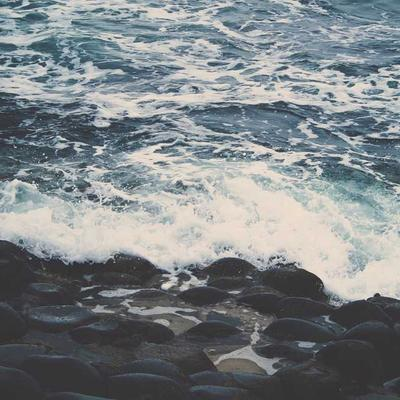

In [11]:
from IPython.display import Image, display

display(Image(filename="imagem_aleatoria.jpg"))

# Nível 3 — Web Scraping e ética
Exercício 3.1 — Verificando o robots.txt

In [12]:
import requests

robots_url = "https://books.toscrape.com/robots.txt"

resposta = requests.get(robots_url, timeout=10)

print("Status:", resposta.status_code)
print(resposta.text)

Status: 404
<html>
<head><title>404 Not Found</title></head>
<body>
<center><h1>404 Not Found</h1></center>
<hr><center>nginx/1.21.6</center>
</body>
</html>



Exercício 3.2 — Extraindo os 5 primeiros livros

In [13]:
import requests
from bs4 import BeautifulSoup

url = "https://books.toscrape.com/"

resposta = requests.get(url, timeout=10)
resposta.raise_for_status()

# Converte o HTML em uma estrutura navegável
soup = BeautifulSoup(resposta.text, "html.parser")

In [14]:
livros = soup.select("article.product_pod")

dados_livros = []

for livro in livros[:5]:
    titulo = livro.h3.a["title"]
    preco = livro.select_one(".price_color").text

    dados_livros.append({
        "titulo": titulo,
        "preco": preco
    })

dados_livros

[{'titulo': 'A Light in the Attic', 'preco': 'Â£51.77'},
 {'titulo': 'Tipping the Velvet', 'preco': 'Â£53.74'},
 {'titulo': 'Soumission', 'preco': 'Â£50.10'},
 {'titulo': 'Sharp Objects', 'preco': 'Â£47.82'},
 {'titulo': 'Sapiens: A Brief History of Humankind', 'preco': 'Â£54.23'}]

In [15]:
for livro in dados_livros:
    print("Título:", livro["titulo"])
    print("Preço:", livro["preco"])
    print("-" * 50)



Título: A Light in the Attic
Preço: Â£51.77
--------------------------------------------------
Título: Tipping the Velvet
Preço: Â£53.74
--------------------------------------------------
Título: Soumission
Preço: Â£50.10
--------------------------------------------------
Título: Sharp Objects
Preço: Â£47.82
--------------------------------------------------
Título: Sapiens: A Brief History of Humankind
Preço: Â£54.23
--------------------------------------------------


Exercício 3.3 — Salvando em CSV

In [16]:
df_livros = pd.DataFrame(dados_livros)

df_livros

,titulo,preco
0,A Light in the Attic,Â£51.77
1,Tipping the Velvet,Â£53.74
2,Soumission,Â£50.10
3,Sharp Objects,Â£47.82
4,Sapiens: A Brief History of Humankind,Â£54.23


In [17]:
df_livros.to_csv(
    "livros.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo livros.csv criado com sucesso!")

Arquivo livros.csv criado com sucesso!


In [18]:
from google.colab import files

files.download("livros.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Exercício 3.4 — Wikipedia + read_html()

In [19]:
import pandas as pd
from io import StringIO
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_and_dependencies_by_population"

resposta = requests.get(
    url,
    headers={"User-Agent": "MeuProjetoPython/1.0"},
    timeout=10
)

resposta.raise_for_status()

# Converte o conteúdo HTML para StringIO
html = StringIO(resposta.text)

# Lê as tabelas existentes na página
tabelas = pd.read_html(html)

print("Quantidade de tabelas encontradas:", len(tabelas))

Quantidade de tabelas encontradas: 4


In [20]:
for i, tabela in enumerate(tabelas):
    print(f"Tabela {i}: {tabela.shape}")

Tabela 0: (241, 6)
Tabela 1: (1, 2)
Tabela 2: (13, 2)
Tabela 3: (1, 2)


In [21]:
df_populacao = tabelas[0]

df_populacao.head()

,Location,Population,% of world,Date,Source (official or from the United Nations),Notes
0,World,8.232000e+09,100%,13 Jun 2025,UN projection[1][3],NaN
1,India,1.429404e+09,17.3%,1 Jul 2026,Official projection[4],[b]
2,China,1.404890e+09,17.0%,31 Dec 2025,Official estimate[5],[c]
3,United States,3.417849e+08,4.1%,1 Jul 2025,Official estimate[6],[d]
4,Indonesia,2.883151e+08,3.5%,31 Dec 2025,National annual projection[7],NaN


In [22]:
df_populacao.columns

Index(['Location', 'Population', '% of world', 'Date',
       'Source (official or from the United Nations)', 'Notes'],
      dtype='object')

In [23]:
df_populacao.to_csv(
    "populacao_paises.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Tabela salva com sucesso!")

Tabela salva com sucesso!
